# BiLSTM Supervisado v2 — Solo Attack_v0 (estrategia corregida)
## Clasificador binario por ventana | 106 features

---

## Por que v1 fallo: el problema de mezclar Normal_v1 con Attack_v0

En v1 se combino Normal_v1 (495k filas, 7 dias) con Attack_v0 (449k filas, 4 dias)
para el entrenamiento. Aunque parece logico dar mas datos normales al modelo,
esto introdujo un problema conceptual critico:

```
Normal_v1 y Attack_v0 son periodos TEMPORALES DISTINTOS de diciembre 2015.
Tienen distribuciones ligeramente diferentes:
  - Distintos niveles base en tanques (LIT101, LIT301, LIT401)
  - Distintas concentraciones quimicas en sensores AIT
  - Distintos estados operacionales acumulados
```

El resultado: el modelo no aprendio 'ataque vs normal'. Aprendio
'datos del periodo Normal_v1 vs datos del periodo Attack_v0'.
Como Normal_v1 siempre tiene label=0, encontro la senal trivial de
identificar a que dataset pertenece cada muestra:

```
Train: Normal_v1 (label=0 siempre) + Attack_v0[:60%] (label 0/1)
Val:   Attack_v0[60-80%]

El modelo aprende: 'Normal_v1-style' = 0, 'Attack_v0-style' = puede ser 1
Al evaluar: todos los datos de val (Attack_v0) parecen 'potencialmente ataque'
Resultado: FPR=0.35, AUC=0.55 (aleatorio), F1=0.086
```

## La estrategia correcta: solo Attack_v0

Attack_v0 contiene periodos normales Y de ataque en el MISMO contexto temporal.
Al hacer un split temporal dentro de el, el modelo aprende la frontera
normal/ataque dentro de una distribucion consistente.

Normal_v1 es util para modelos NO SUPERVISADOS (aprenden solo de datos normales).
Para modelos supervisados, el contexto temporal consistente es mas importante
que la cantidad bruta de datos normales.

```
Attack_v0 (449,919 filas, 4 dias con ataques intercalados):
  primeras 70% filas -> TRAIN  (normal + ataque, misma distribucion)
  siguientes 15% filas -> VAL  (mismo periodo)
  ultimas 15% filas -> TEST    (mismo periodo)
```

## Otros fixes de v1 a v2

| Problema v1 | Fix v2 |
|-------------|--------|
| LR=1e-3 -> overfitting ep3 | LR=1e-4 (10x menor) |
| Early stop en val_loss (ruidoso con 249 ventanas ataque) | Early stop en F1_val |
| HIDDEN_SIZE=256 (demasiado para datos disponibles) | HIDDEN_SIZE=128 |
| Mezcla Normal_v1 + Attack_v0 | Solo Attack_v0 |
| Val loss divergia en ep10 | Consistencia de distribucion |


## 0. Imports y reproducibilidad

In [1]:
import json, joblib, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas del proyecto

In [2]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

A1A2_DIR    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A1 & A2_Dec 2015'
ATTACK_XLSX = A1A2_DIR / 'SWaT_Dataset_Attack_v0.xlsx'
# Normal_v1 NO se usa en este modelo supervisado.
# Attack_v0 ya contiene periodos normales y de ataque en el mismo
# contexto temporal, lo que garantiza consistencia de distribucion.

SAVE_DIR = PROJECT_ROOT / 'models' / 'detectors' / 'bilstm_swat_a1a2_v2'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('ATTACK_XLSX :', ATTACK_XLSX.exists())
print('SAVE_DIR    :', SAVE_DIR)


ATTACK_XLSX : True
SAVE_DIR    : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\bilstm_swat_a1a2_v2


## 2. Configuracion y decisiones de diseno

### Split temporal 70/15/15 sobre Attack_v0

El split es estrictamente **cronologico** (no aleatorio). El 70% inicial
de filas va a train, el siguiente 15% a val, el ultimo 15% a test.

Esto garantiza:
- El modelo nunca ve datos 'del futuro' durante el entrenamiento
- La distribucion de sensores es consistente en los tres splits
- Los episodios de ataque en val/test son diferentes a los de train

### Variables continuas vs discretas

**Continuas (25 sensores, >10 valores unicos):** nivel, flujo, presion, conductividad.
`StandardScaler` (media=0, std=1) fiteado SOLO en train. Clip a [-5, 5].

**Discretas (26 actuadores, <=10 valores unicos):** valvulas (0/1/2), bombas (0/1).
Normalizacion [0,1] dividiendo por el maximo de train.
NO se usa StandardScaler porque los valores enteros tienen significado categorico.

### Feature engineering: RWSF + TF

Se aplica sobre 8 sensores estacionales (Pinto et al., 2024).
RWSF captura tendencias locales en 120s. TF captura dependencias causales.
Total: 51 + 40 + 15 = 106 features.

### Desbalance de clases

Attack_v0 tiene ~12% de ventanas de ataque. Se usa `pos_weight` en
`BCEWithLogitsLoss` para compensar. El `pos_weight = n_normal / n_attack`
se calcula solo sobre el split de TRAIN.

### Early stopping basado en F1_val

A diferencia de v1 que usaba val_loss (ruidoso con pocas ventanas de ataque),
v2 usa el F1 en validacion como criterio de early stopping. El threshold
para el F1 de monitoreo se busca en val en cada epoca. El modelo se guarda
cuando el F1_val mejora.


In [3]:
# ─── Split ────────────────────────────────────────────────────────────────
TRAIN_FRAC = 0.70   # primeras 70% filas de Attack_v0
VAL_FRAC   = 0.15   # siguientes 15%
# TEST_FRAC = 0.15  # ultimas 15%

# ─── Preprocesamiento ─────────────────────────────────────────────────────
WINDOW_SIZE = 60     # ventana temporal en segundos
STRIDE      = 10     # stride (solapamiento 83%)
CLIP_VAL    = 5.0   # clipping StandardScaler (5 sigmas)

# ─── Feature engineering ──────────────────────────────────────────────────
SEASONAL_SENSOR_BASES = ['FIT101','LIT101','FIT201','DPIT301',
                          'FIT301','LIT301','AIT401','FIT601']
TF_SENSOR_BASES = ['FIT101','LIT101','FIT201','DPIT301','FIT301']
RWSF_WINDOW = 120
TF_LAGS     = [10, 20, 30]

# ─── Arquitectura BiLSTM ──────────────────────────────────────────────────
HIDDEN_SIZE = 128
# v2: 256->128. Con solo 10,000-20,000 ventanas de ataque en train,
# un modelo mas sencillo generaliza mejor y es menos propenso a overfitting.
NUM_LAYERS  = 2
DROPOUT     = 0.3
DROPOUT_CLS = 0.2
FC_HIDDEN   = 64
# v2: 128->64. Coherente con la reduccion de HIDDEN_SIZE.

# ─── Entrenamiento ────────────────────────────────────────────────────────
BATCH_SIZE   = 256
LR           = 1e-4
# v2: 1e-3->1e-4. En v1 el modelo hizo overfitting en solo 3 epocas
# con LR=1e-3. Con 1e-4 el aprendizaje es mas gradual y estable.
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 100
PATIENCE     = 15
# Early stopping en F1_val (no en val_loss).
# Con pocas ventanas de ataque en val, val_loss es ruidoso.
# F1_val es mas estable y directamente la metrica objetivo.

# ─── Evaluacion ───────────────────────────────────────────────────────────
CONSEC_K = 5

print('Configuracion v2:')
print(f'  Dataset: SOLO Attack_v0 (split 70/15/15 temporal)')
print(f'  Features: 106 (51 + 40 RWSF + 15 TF)')
print(f'  BiLSTM: hidden={HIDDEN_SIZE}x2, layers={NUM_LAYERS}, fc={FC_HIDDEN}')
print(f'  LR={LR:.0e} | batch={BATCH_SIZE} | early stop en F1_val')


Configuracion v2:
  Dataset: SOLO Attack_v0 (split 70/15/15 temporal)
  Features: 106 (51 + 40 RWSF + 15 TF)
  BiLSTM: hidden=128x2, layers=2, fc=64
  LR=1e-04 | batch=256 | early stop en F1_val


## 3. Carga de Attack_v0 y split temporal

Attack_v0 tiene:
- 449,919 filas de 4 dias con ataques intercalados
- ~88% filas normales (label=0) y ~12% de ataque (label=1)
- 41 escenarios de ataque (ver Tabla 1, Pinto et al. 2024)

El split temporal garantiza que los episodios de ataque en val y test
son diferentes a los del train, simulando el escenario real donde
el modelo debe detectar tipos de ataque no vistos exactamente igual.

In [4]:
print('Cargando Attack_v0.xlsx...')
df = pd.read_excel(ATTACK_XLSX, header=1, engine='openpyxl')
df.columns = df.columns.str.strip()
print(f'Filas totales: {len(df):,}')

# Timestamp
ts_cols = [c for c in df.columns if 'timestamp' in c.lower()]
if ts_cols:
    df['t_stamp'] = pd.to_datetime(df[ts_cols[0]], errors='coerce')
    df = df.sort_values('t_stamp').reset_index(drop=True)

# Label: columna 'Normal/Attack'
lbl_cols = [c for c in df.columns
            if ('normal' in c.lower() or 'attack' in c.lower())
            and c != 't_stamp']
assert lbl_cols, 'No se encontro columna de label'
df['attack_label'] = (df[lbl_cols[0]].astype(str).str.strip() == 'Attack').astype(int)
print(f'Label col: {lbl_cols[0]}')
print(f'Ataques: {df["attack_label"].sum():,} ({100*df["attack_label"].mean():.1f}%)')

# Columnas de sensores
non_sensor = ['t_stamp', 'attack_label'] + ts_cols + lbl_cols
all_sensor_cols = [c for c in df.columns if c not in non_sensor]
print(f'Columnas sensor: {len(all_sensor_cols)}')

# Convertir a numerico
for col in all_sensor_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Split temporal 70/15/15
n   = len(df)
t1  = int(n * TRAIN_FRAC)
t2  = int(n * (TRAIN_FRAC + VAL_FRAC))

df_train = df.iloc[:t1].copy().reset_index(drop=True)
df_val   = df.iloc[t1:t2].copy().reset_index(drop=True)
df_test  = df.iloc[t2:].copy().reset_index(drop=True)

print()
print('='*58)
print('SPLIT TEMPORAL DE ATTACK_v0')
print('='*58)
for name, d in [('TRAIN', df_train), ('VAL', df_val), ('TEST', df_test)]:
    n1 = d['attack_label'].sum(); n0 = len(d)-n1
    print(f'{name}: {len(d):,} filas | '
          f'normal={n0:,} ({100*n0/len(d):.1f}%) | '
          f'ataque={n1:,} ({100*n1/len(d):.1f}%)')
print('='*58)


Cargando Attack_v0.xlsx...
Filas totales: 449,919
Label col: Normal/Attack
Ataques: 54,584 (12.1%)
Columnas sensor: 51

SPLIT TEMPORAL DE ATTACK_v0
TRAIN: 314,943 filas | normal=265,664 (84.4%) | ataque=49,279 (15.6%)
VAL: 67,488 filas | normal=65,861 (97.6%) | ataque=1,627 (2.4%)
TEST: 67,488 filas | normal=63,810 (94.6%) | ataque=3,678 (5.4%)


## 4. Clasificacion de variables y feature engineering

### Por que separar continuas y discretas

El sistema SWaT tiene dos tipos fundamentalmente distintos de variables:

**Sensores continuos (25):** flujos, niveles, presiones, conductividad.
Su distribucion varia segun las condiciones de operacion.
`StandardScaler` los centra y escala para que ninguno domine por tener
una escala fisica mayor (ej: LIT101 en mm vs FIT101 en m3/h).

**Actuadores discretos (26):** valvulas (estado 0/1/2), bombas (0/1).
Sus valores son CATEGORICOS, no numericos. Escalarlos con StandardScaler
destruiria su semantica (ej: centrar {0,1,2} a {-1,0,1} pierde el
significado de 'cerrado/parcial/abierto').
La normalizacion [0,1] por maximo preserva la estructura ordinal.

### Feature engineering (RWSF + TF)

Se aplica ANTES del escalado, sobre los valores fisicos originales.
El scaler luego normaliza tambien las features nuevas (que son
transformaciones lineales de los sensores continuos).

In [5]:
def classify_columns(df, sensor_cols, threshold=10):
    continuous = [c for c in sensor_cols if df[c].nunique() > threshold]
    discrete   = [c for c in sensor_cols if c not in continuous]
    return continuous, discrete


def resolve_sensors(bases, available):
    resolved = []
    for base in bases:
        m = [c for c in available
             if c == base or c.startswith(base+'.') or c.startswith(base+' ')]
        if not m:
            m = [c for c in available if c.lower().startswith(base.lower())]
        if m: resolved.append(m[0])
    return resolved


def add_features(df, seasonal, tf_sensors, rwsf_win, lags):
    """Agrega RWSF y TF. Se aplica antes del escalado.
    NaN por rolling/shift se imputan con la mediana de la columna."""
    df = df.copy(); new = []
    for s in seasonal:
        if s not in df.columns: continue
        base = s.replace('.Pv','').replace(' ','_')
        for stat in ['mean','median','std','max','min']:
            cn = f'{base}__rwsf_{stat}'
            df[cn] = getattr(df[s].rolling(rwsf_win), stat)()
            new.append(cn)
    for s in tf_sensors:
        if s not in df.columns: continue
        base = s.replace('.Pv','').replace(' ','_')
        for lag in lags:
            cn = f'{base}__lag{lag}'
            df[cn] = df[s].shift(lag)
            new.append(cn)
    df[new] = df[new].fillna(df[new].median())
    return df, new


# Clasificar columnas usando train (mas representativo)
continuous_cols, discrete_cols = classify_columns(df_train, all_sensor_cols)
print(f'Continuas: {len(continuous_cols)} | Discretas: {len(discrete_cols)}')
print(f'Discretas: {discrete_cols}')

SEASONAL = resolve_sensors(SEASONAL_SENSOR_BASES, all_sensor_cols)
TF_SENS  = resolve_sensors(TF_SENSOR_BASES, all_sensor_cols)
print(f'\nSensores estacionales: {SEASONAL}')
print(f'Sensores TF:           {TF_SENS}')

# Feature engineering en los tres splits
df_train, fe_cols = add_features(df_train, SEASONAL, TF_SENS, RWSF_WINDOW, TF_LAGS)
df_val,   _       = add_features(df_val,   SEASONAL, TF_SENS, RWSF_WINDOW, TF_LAGS)
df_test,  _       = add_features(df_test,  SEASONAL, TF_SENS, RWSF_WINDOW, TF_LAGS)

all_cont_cols    = continuous_cols + fe_cols
all_feature_cols = all_cont_cols + discrete_cols
print(f'\nFeatures: {len(continuous_cols)} cont + {len(fe_cols)} FE + {len(discrete_cols)} disc = {len(all_feature_cols)} total')


Continuas: 25 | Discretas: 26
Discretas: ['MV101', 'P101', 'P102', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'P401', 'P402', 'P403', 'P404', 'UV401', 'P501', 'P502', 'P601', 'P602', 'P603']

Sensores estacionales: ['FIT101', 'LIT101', 'FIT201', 'DPIT301', 'FIT301', 'LIT301', 'AIT401', 'FIT601']
Sensores TF:           ['FIT101', 'LIT101', 'FIT201', 'DPIT301', 'FIT301']

Features: 25 cont + 55 FE + 26 disc = 106 total


## 5. Escalado

### Regla de oro: fitear el scaler SOLO en train

Si el scaler viera los datos de val o test, el modelo tendria informacion
del futuro (data leakage). Esto infla artificialmente las metricas.
El scaler se fitea en train y se aplica con los MISMOS parametros a val/test.

### Imputacion de NaN

Los valores `Bad Input` en los sensores se convirtieron a NaN al cargar.
Se imputan con la mediana de cada columna calculada en TRAIN.
La mediana es mas robusta que la media ante outliers en sensores industriales.

In [6]:
# Imputar NaN con mediana de train
train_median = df_train[all_sensor_cols].median()
for split_df in [df_train, df_val, df_test]:
    split_df[all_sensor_cols] = split_df[all_sensor_cols].fillna(train_median)
    # FE cols tambien pueden tener NaN residuales
    split_df[fe_cols] = split_df[fe_cols].fillna(split_df[fe_cols].median())

# Scaler continuas: fitear en train
scaler_cont = StandardScaler()
scaler_cont.fit(df_train[all_cont_cols].values)

# Maximo discretas: calcular en train
disc_max = df_train[discrete_cols].max().replace(0, 1)
disc_max_dict = disc_max.to_dict()

def scale_df(df):
    """Escala usando parametros de train.
    Continuas + FE: StandardScaler -> clip[-5,5]
    Discretas: divide por max de train -> [0,1]
    """
    df = df.copy()
    df[all_cont_cols] = np.clip(
        scaler_cont.transform(df[all_cont_cols].values), -CLIP_VAL, CLIP_VAL)
    df[discrete_cols] = (df[discrete_cols] / disc_max).clip(0, 1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

print('Verificacion escalado (train):')
print(f'  Continuas media: {df_train_sc[continuous_cols].values.mean():.4f} (esperado ~0)')
print(f'  Continuas std:   {df_train_sc[continuous_cols].values.std():.4f}  (esperado ~1)')
print(f'  Discretas rango: [{df_train_sc[discrete_cols].values.min():.2f}, '
      f'{df_train_sc[discrete_cols].values.max():.2f}] (esperado [0,1])')

joblib.dump(scaler_cont,   SAVE_DIR / 'scaler_cont.pkl')
joblib.dump(disc_max_dict, SAVE_DIR / 'disc_max_dict.pkl')
print('Scaler guardado.')


Verificacion escalado (train):
  Continuas media: -0.0026 (esperado ~0)
  Continuas std:   0.9580  (esperado ~1)
  Discretas rango: [0.00, 1.00] (esperado [0,1])
Scaler guardado.


## 6. Construccion de ventanas y manejo del desbalance

### Label por ventana: estrategia 'any-attack'

Una ventana recibe label=1 si AL MENOS UN timestep en ella es ataque.
Alternativa: label=1 si la mayoria (>50%) es ataque. La estrategia
'any-attack' es mas conservadora y asegura que no perdamos ataques cortos.

### Desbalance de clases y pos_weight

Con ~12% de ventanas de ataque, el modelo sin compensacion ignoraria
los ataques (predecir siempre 'normal' da 88% de exactitud pero F1~0).

`BCEWithLogitsLoss(pos_weight=w)` equivale a:
```
L = -(w * y * log(p) + (1-y) * log(1-p))
```
Con w = n_normal/n_attack, la perdida de cada ejemplo de ataque se
multiplica por w, haciendo que el modelo los trate como si hubiera w
veces mas ejemplos de ataque. Esto balancea el gradiente efectivamente.

VENTANAS CONSTRUIDAS
TRAIN: 31,489 ventanas | normal=26,414 (83.9%) | ataque=5,075 (16.1%)
VAL: 6,743 ventanas | normal=6,556 (97.2%) | ataque=187 (2.8%)
TEST: 6,743 ventanas | normal=6,342 (94.1%) | ataque=401 (5.9%)
pos_weight: 5.20 (n_normal/n_attack en train)


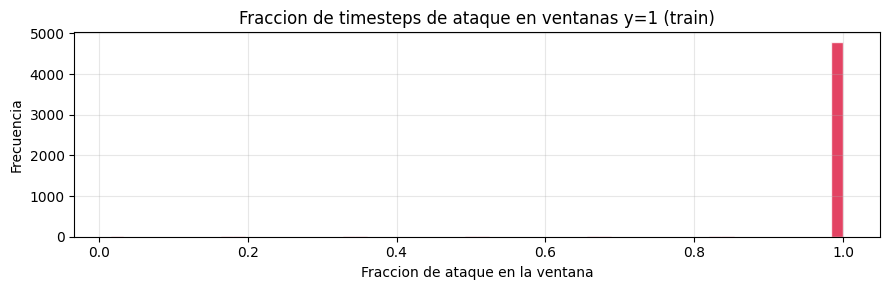

In [7]:
def make_windows(df_sc, df_orig, feat_cols, ws, stride):
    """Ventanas deslizantes con label 'any-attack' por ventana."""
    arr  = df_sc[feat_cols].values.astype(np.float32)
    lbls = df_orig['attack_label'].values
    Xs, ys, fracs = [], [], []
    for i in range(0, len(arr)-ws+1, stride):
        seg = lbls[i:i+ws]
        Xs.append(arr[i:i+ws])
        ys.append(int(np.any(seg==1)))
        fracs.append(float(np.mean(seg)))
    return (np.array(Xs, dtype=np.float32),
            np.array(ys, dtype=np.float32),
            np.array(fracs, dtype=np.float32))


X_tr, y_tr, fr_tr = make_windows(df_train_sc, df_train, all_feature_cols, WINDOW_SIZE, STRIDE)
X_va, y_va, fr_va = make_windows(df_val_sc,   df_val,   all_feature_cols, WINDOW_SIZE, STRIDE)
X_te, y_te, fr_te = make_windows(df_test_sc,  df_test,  all_feature_cols, WINDOW_SIZE, STRIDE)

print('='*58)
print('VENTANAS CONSTRUIDAS')
print('='*58)
for nm, X, y in [('TRAIN',X_tr,y_tr),('VAL',X_va,y_va),('TEST',X_te,y_te)]:
    n1=int(y.sum()); n0=len(y)-n1
    print(f'{nm}: {len(X):,} ventanas | '
          f'normal={n0:,} ({100*n0/len(y):.1f}%) | '
          f'ataque={n1:,} ({100*n1/len(y):.1f}%)')
print('='*58)

n0_tr = (y_tr==0).sum(); n1_tr = (y_tr==1).sum()
pos_weight = float(n0_tr / max(n1_tr, 1))
print(f'pos_weight: {pos_weight:.2f} (n_normal/n_attack en train)')

# Visualizacion distribucion de fracciones de ataque
fig, ax = plt.subplots(figsize=(9, 3))
ax.hist(fr_tr[y_tr==1], bins=60, color='crimson', alpha=0.8, edgecolor='white')
ax.set_title('Fraccion de timesteps de ataque en ventanas y=1 (train)')
ax.set_xlabel('Fraccion de ataque en la ventana')
ax.set_ylabel('Frecuencia'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'attack_fraction_dist.png'), dpi=120); plt.show()


## 7. Arquitectura BiLSTM

La BiLSTM procesa la ventana en ambas direcciones:
- **Forward:** aprende que patrones PRECEDEN a los ataques
- **Backward:** aprende que patrones SIGUEN a los ataques

Esto es especialmente util en SWaT porque algunos ataques tienen
efectos retardados: el nivel del tanque baja gradualmente DESPUES
de que se cierra una valvula. La direccion backward puede detectar
que 'algo raro paso antes' al ver el efecto posterior.

```
Input (60, 106)
  -> BiLSTM(128, 2 capas, bidireccional)
     h_forward[-1] || h_backward[-1]  -> (256,)
  -> Dropout(0.3)
  -> Linear(256, 64) -> ReLU -> Dropout(0.2)
  -> Linear(64, 1)  [logit, sin sigmoid]
```

La salida es un LOGIT (no probabilidad). `BCEWithLogitsLoss` aplica
el sigmoid internamente, lo que es numericamente mas estable.
Para obtener probabilidades en inferencia: `torch.sigmoid(logit)`.

In [8]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden_size=128, num_layers=2,
                 fc_hidden=64, dropout=0.3, dropout_cls=0.2):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden_size,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.drop1 = nn.Dropout(dropout)
        self.fc1   = nn.Linear(hidden_size * 2, fc_hidden)  # *2 por bidireccional
        self.relu  = nn.ReLU()
        self.drop2 = nn.Dropout(dropout_cls)
        self.fc2   = nn.Linear(fc_hidden, 1)
        # Sin sigmoid: BCEWithLogitsLoss lo incluye internamente

    def forward(self, x):
        _, (hn, _) = self.bilstm(x)
        h = torch.cat([hn[-2], hn[-1]], dim=1)  # fwd + bck ultima capa
        return self.fc2(self.drop2(self.relu(self.fc1(self.drop1(h))))).squeeze(1)


n_feat = X_tr.shape[2]
model  = BiLSTMClassifier(
    n_features=n_feat, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
    fc_hidden=FC_HIDDEN, dropout=DROPOUT, dropout_cls=DROPOUT_CLS
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f'BiLSTM v2: hidden={HIDDEN_SIZE}x2={HIDDEN_SIZE*2} | '
      f'layers={NUM_LAYERS} | fc={FC_HIDDEN}')
print(f'Parametros: {n_params:,}')
print(f'Input shape: (batch, {WINDOW_SIZE}, {n_feat})')


BiLSTM v2: hidden=128x2=256 | layers=2 | fc=64
Parametros: 653,441
Input shape: (batch, 60, 106)


## 8. Entrenamiento con early stopping en F1_val

### Por que F1 y no val_loss para early stopping

Con un desbalance de ~90%/10% en las ventanas, la val_loss puede
verse dominada por la clase mayoritaria (normal), haciendo que el
modelo 'mejore' la val_loss simplemente siendo mas conservador
(prediciendo menos ataques). El F1 penaliza directamente tanto
los falsos negativos (ataques perdidos) como los falsos positivos.

### Scheduler

`ReduceLROnPlateau` sobre val_loss con factor=0.5 y patience=7.
Reduce el LR cuando la perdida deja de mejorar, permitiendo
convergencia mas fina en las etapas finales del entrenamiento.

In [9]:
tr_ldr = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
                    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
va_ldr = DataLoader(TensorDataset(torch.tensor(X_va), torch.tensor(y_va)),
                    batch_size=BATCH_SIZE, shuffle=False)

pw   = torch.tensor([pos_weight], dtype=torch.float32).to(device)
crit = nn.BCEWithLogitsLoss(pos_weight=pw)
opt  = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(
           opt, 'min', factor=0.5, patience=7, min_lr=1e-7)

best_f1 = -1.0; best_wts = None; no_imp = 0; best_ep = 1
tr_hist = []; va_hist = []; f1_hist = []

for ep in range(1, MAX_EPOCHS+1):
    # ── Train ──
    model.train(); tl = 0.0
    for xb, yb in tr_ldr:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tl += loss.item()
    tl /= len(tr_ldr)

    # ── Val ──
    model.eval(); vl = 0.0
    all_p, all_y = [], []
    with torch.no_grad():
        for xb, yb in va_ldr:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            vl += crit(logits, yb).item()
            all_p.extend(torch.sigmoid(logits).cpu().numpy())
            all_y.extend(yb.cpu().numpy())
    vl /= len(va_ldr)
    sch.step(vl)

    # ── F1 en val (sweep rapido) ──
    pv = np.array(all_p); yv = np.array(all_y).astype(int)
    ep_f1 = 0.0
    for tau in np.linspace(0.05, 0.95, 100):
        pr = (pv > tau).astype(int)
        tp_ = int(((pr==1)&(yv==1)).sum())
        fp_ = int(((pr==1)&(yv==0)).sum())
        fn_ = int(((pr==0)&(yv==1)).sum())
        p_  = tp_/(tp_+fp_+1e-10); r_ = tp_/(tp_+fn_+1e-10)
        f_  = 2*p_*r_/(p_+r_+1e-10)
        if f_ > ep_f1: ep_f1 = f_

    tr_hist.append(tl); va_hist.append(vl); f1_hist.append(ep_f1)

    # ── Early stopping en F1_val ──
    if ep_f1 > best_f1 + 1e-5:
        best_f1 = ep_f1; best_ep = ep; no_imp = 0
        best_wts = {k: v.clone() for k,v in model.state_dict().items()}
    else:
        no_imp += 1

    if ep % 10 == 0:
        print(f'Ep {ep:4d} | Train:{tl:.4f} | Val:{vl:.4f} | '
              f'F1_val:{ep_f1:.3f} | Best F1:{best_f1:.3f}(ep{best_ep})')
    if no_imp >= PATIENCE:
        print(f'Early stop ep{ep}. Mejor F1_val={best_f1:.3f} en ep{best_ep}.'); break

model.load_state_dict(best_wts); model.eval()
print(f'\nModelo restaurado al ep{best_ep} (F1_val={best_f1:.3f})')


Ep   10 | Train:0.0857 | Val:0.6575 | F1_val:0.299 | Best F1:0.489(ep2)
Early stop ep17. Mejor F1_val=0.489 en ep2.

Modelo restaurado al ep2 (F1_val=0.489)


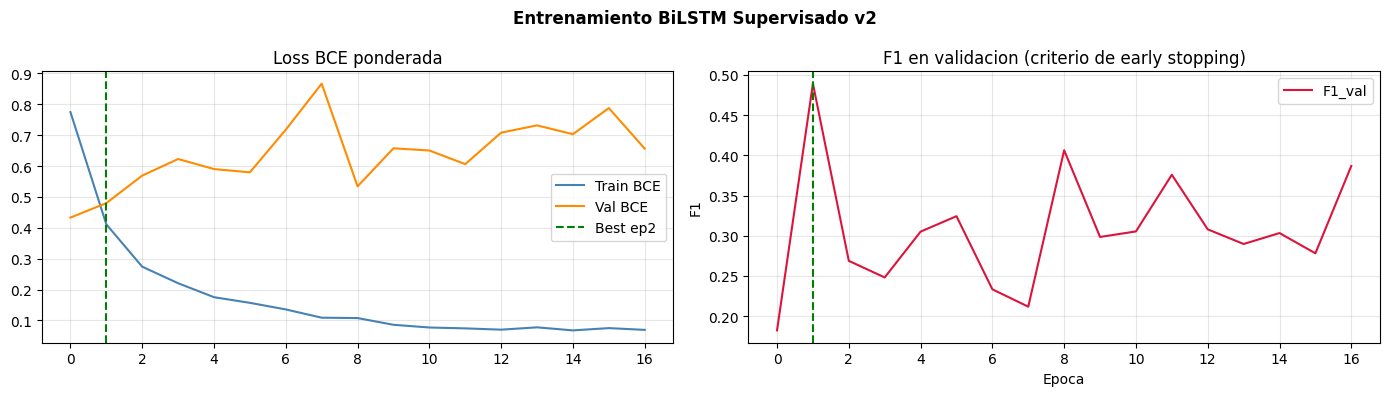

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(tr_hist, color='steelblue', label='Train BCE')
axes[0].plot(va_hist, color='darkorange', label='Val BCE')
axes[0].axvline(best_ep-1, color='green', linestyle='--', lw=1.5, label=f'Best ep{best_ep}')
axes[0].set_title('Loss BCE ponderada'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(f1_hist, color='crimson', label='F1_val')
axes[1].axvline(best_ep-1, color='green', linestyle='--', lw=1.5)
axes[1].set_title('F1 en validacion (criterio de early stopping)')
axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('F1')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Entrenamiento BiLSTM Supervisado v2', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'training_curves.png'), dpi=120)
plt.show()


## 9. Seleccion de threshold en VALIDACION

El threshold se selecciona en val (no en test) para evitar data leakage.
Se hace un sweep de 500 valores en [0.01, 0.99], evaluando el F1 con
el filtro de ventanas consecutivas CONSEC_K=5.

**CONSEC_K=5:** una ventana se marca como ataque solo si ella y las 4
anteriores superan el threshold. Con el modelo supervisado que ya aprendio
la frontera directamente, k=5 (50 segundos) es suficiente para suavizar
falsos positivos esporadicos sin perder muchos ataques cortos.

Threshold optimo (VAL): 0.9095 | F1_val: 0.482


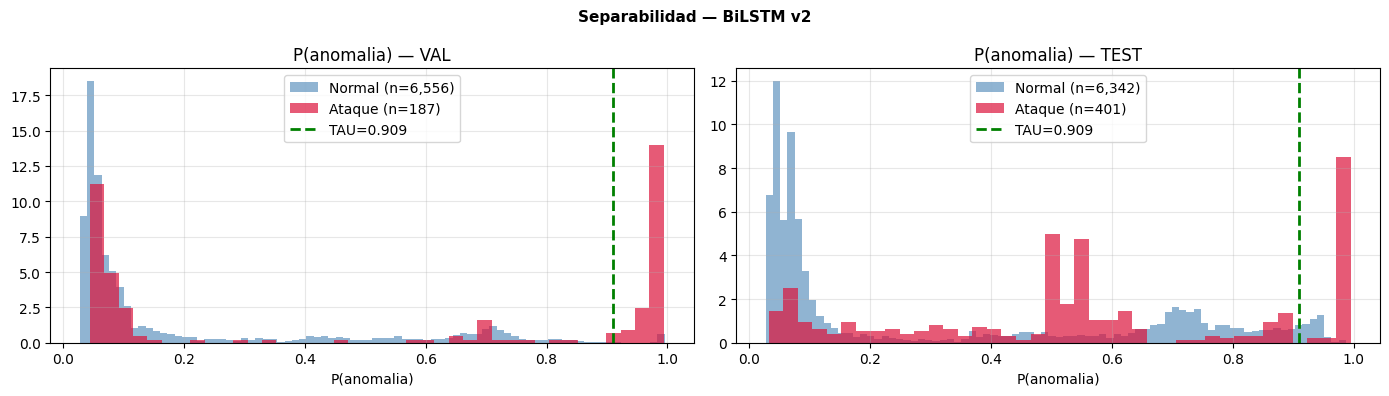

In [11]:
def get_probs(model, X, bs=512):
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            xb = torch.tensor(X[i:i+bs]).to(device)
            probs.extend(torch.sigmoid(model(xb)).cpu().numpy())
    return np.array(probs)


def consec_filter(scores, tau, k):
    raw = (scores > tau).astype(int)
    if k <= 1: return raw
    out = np.zeros_like(raw)
    for ii in range(k-1, len(raw)):
        out[ii] = int(raw[ii-k+1:ii+1].all())
    return out


def sweep_threshold(probs, y, k, n=500):
    taus = np.linspace(0.01, 0.99, n)
    bf1 = -1; btau = 0.5
    for tau in taus:
        pr = consec_filter(probs, tau, k)
        tp = int(((pr==1)&(y==1)).sum())
        fp = int(((pr==1)&(y==0)).sum())
        fn = int(((pr==0)&(y==1)).sum())
        pp = tp/(tp+fp+1e-10); rr = tp/(tp+fn+1e-10)
        ff = 2*pp*rr/(pp+rr+1e-10)
        if ff > bf1: bf1 = ff; btau = float(tau)
    return btau, bf1


probs_val  = get_probs(model, X_va)
probs_test = get_probs(model, X_te)

TAU, f1_val_opt = sweep_threshold(probs_val, y_va.astype(int), CONSEC_K)
print(f'Threshold optimo (VAL): {TAU:.4f} | F1_val: {f1_val_opt:.3f}')

# Distribucion de probabilidades
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, probs, y, title in [
    (axes[0], probs_val, y_va,  'VAL'),
    (axes[1], probs_test, y_te, 'TEST')
]:
    y_int = y.astype(int)
    ax.hist(probs[y_int==0], bins=80, alpha=0.6, density=True,
            color='steelblue', label=f'Normal (n={(y_int==0).sum():,})')
    ax.hist(probs[y_int==1], bins=40, alpha=0.7, density=True,
            color='crimson',   label=f'Ataque (n={(y_int==1).sum():,})')
    ax.axvline(TAU, color='green', lw=2, linestyle='--', label=f'TAU={TAU:.3f}')
    ax.set_title(f'P(anomalia) — {title}')
    ax.set_xlabel('P(anomalia)'); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Separabilidad — BiLSTM v2', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'prob_distributions.png'), dpi=120)
plt.show()


## 10. Metricas en TEST

In [12]:
y_te_int = y_te.astype(int)
pr_test  = consec_filter(probs_test, TAU, CONSEC_K)
tp  = int(((pr_test==1)&(y_te_int==1)).sum())
fp  = int(((pr_test==1)&(y_te_int==0)).sum())
fn  = int(((pr_test==0)&(y_te_int==1)).sum())
tn  = int(((pr_test==0)&(y_te_int==0)).sum())
prec = tp/(tp+fp+1e-10); rec = tp/(tp+fn+1e-10)
f1   = 2*prec*rec/(prec+rec+1e-10)
fpr  = fp/(fp+tn+1e-10)
auc  = roc_auc_score(y_te_int, probs_test)
prauc= average_precision_score(y_te_int, probs_test)

print('='*60)
print('RESULTADOS BiLSTM v2 — TEST')
print('='*60)
print(f'  AUC-ROC:   {auc:.4f}')
print(f'  PR-AUC:    {prauc:.4f}')
print(f'  F1:        {f1:.3f}')
print(f'  Recall:    {rec:.3f}')
print(f'  Precision: {prec:.3f}')
print(f'  FPR:       {fpr:.3f}')
print(f'  TAU:       {TAU:.4f} (optimo en VAL)')
print(f'  TP={tp} | FP={fp} | FN={fn} | TN={tn}')
print('='*60)
print(f'  Referencia VAE-LSTM no supervisado v2: F1=0.748')


RESULTADOS BiLSTM v2 — TEST
  AUC-ROC:   0.7101
  PR-AUC:    0.2896
  F1:        0.211
  Recall:    0.175
  Precision: 0.266
  FPR:       0.030
  TAU:       0.9095 (optimo en VAL)
  TP=70 | FP=193 | FN=331 | TN=6149
  Referencia VAE-LSTM no supervisado v2: F1=0.748


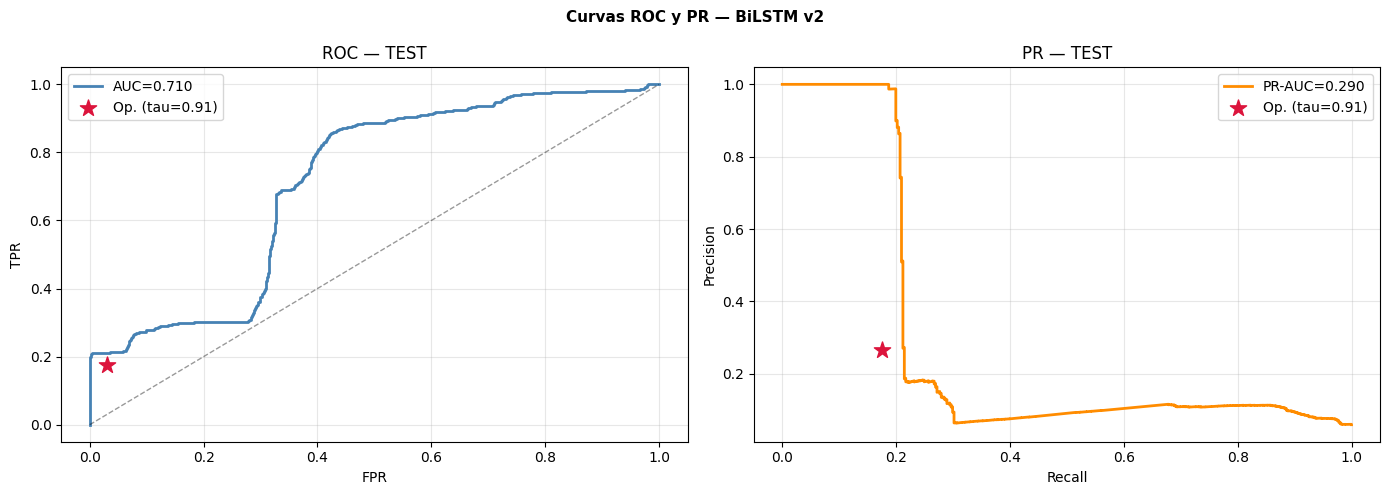

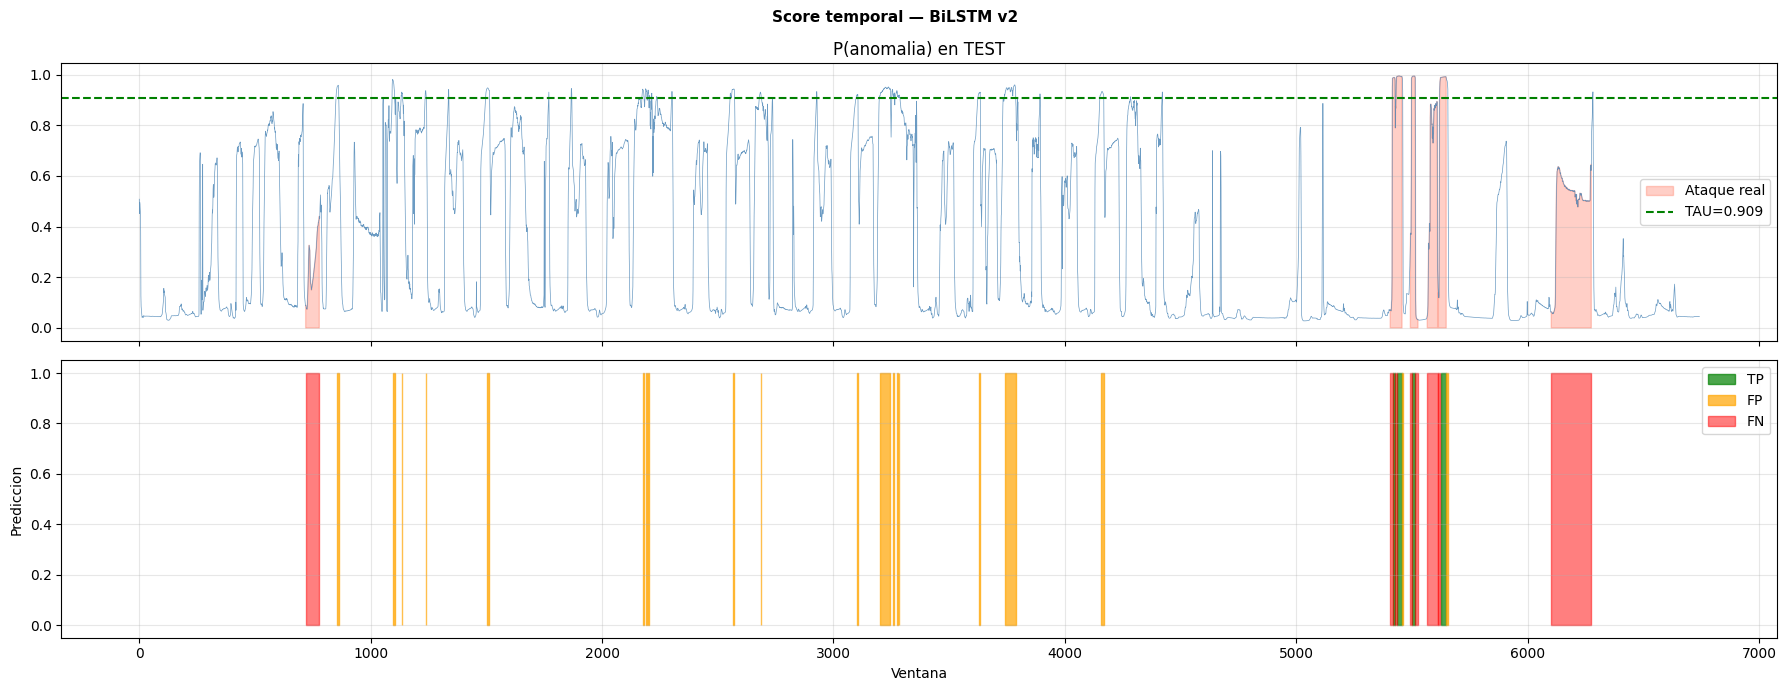

In [13]:
# ROC y PR
fpr_c, tpr_c, _ = roc_curve(y_te_int, probs_test)
prc_c, rec_c, _ = precision_recall_curve(y_te_int, probs_test)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(fpr_c, tpr_c, lw=2, color='steelblue', label=f'AUC={auc:.3f}')
axes[0].scatter(fpr, rec, s=150, color='crimson', zorder=5, marker='*',
                label=f'Op. (tau={TAU:.2f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — TEST'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(rec_c, prc_c, lw=2, color='darkorange', label=f'PR-AUC={prauc:.3f}')
axes[1].scatter(rec, prec, s=150, color='crimson', zorder=5, marker='*',
                label=f'Op. (tau={TAU:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR — TEST'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Curvas ROC y PR — BiLSTM v2', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'roc_pr_curves.png'), dpi=120)
plt.show()

# Score temporal
t_idx = np.arange(len(probs_test))
fig, axes = plt.subplots(2, 1, figsize=(18, 7), sharex=True)
axes[0].plot(t_idx, probs_test, lw=0.5, color='steelblue', alpha=0.8)
axes[0].fill_between(t_idx, 0, probs_test, where=(y_te_int==1),
                     color='tomato', alpha=0.3, label='Ataque real')
axes[0].axhline(TAU, color='green', lw=1.5, linestyle='--', label=f'TAU={TAU:.3f}')
axes[0].set_title(f'P(anomalia) en TEST'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].fill_between(t_idx,0,pr_test.astype(float),where=(pr_test==1)&(y_te_int==1),
                     color='green',  alpha=0.7, label='TP')
axes[1].fill_between(t_idx,0,pr_test.astype(float),where=(pr_test==1)&(y_te_int==0),
                     color='orange', alpha=0.7, label='FP')
axes[1].fill_between(t_idx,0,(y_te_int==1).astype(float),where=(pr_test==0)&(y_te_int==1),
                     color='red',    alpha=0.5, label='FN')
axes[1].set_xlabel('Ventana'); axes[1].set_ylabel('Prediccion')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Score temporal — BiLSTM v2', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'score_temporal.png'), dpi=120)
plt.show()


Episodio  Ventanas  Detectadas  Tasa (%)
  Atk 01        60           0       0.0
  Atk 02        52          32      61.5
  Atk 03        34          13      38.2
  Atk 04        46           0       0.0
  Atk 05        35          25      71.4
  Atk 06       174           0       0.0


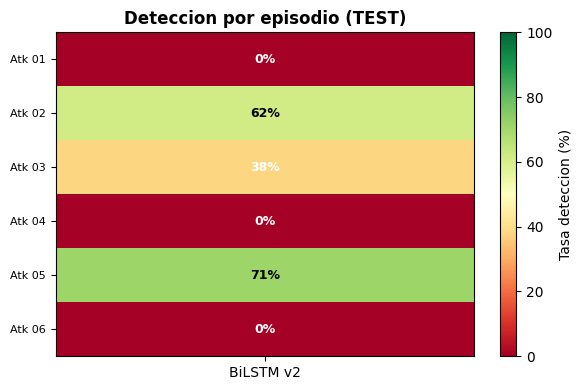

In [14]:
# Reconstruir IDs de episodio en test
lbls_te = df_test['attack_label'].values
aid_raw = np.zeros(len(df_test), dtype=float)
cid = 0; in_a = False
for i in range(len(lbls_te)):
    if lbls_te[i]==1 and not in_a: cid+=1; in_a=True
    elif lbls_te[i]==0: in_a=False
    if lbls_te[i]==1: aid_raw[i]=float(cid)

aids_win = []
for i in range(0, len(lbls_te)-WINDOW_SIZE+1, STRIDE):
    seg_l = lbls_te[i:i+WINDOW_SIZE]
    seg_a = aid_raw[i:i+WINDOW_SIZE]
    if np.any(seg_l==1):
        u,c = np.unique(seg_a[seg_l==1], return_counts=True)
        aids_win.append(float(u[c.argmax()]))
    else:
        aids_win.append(0.0)
aids_win = np.array(aids_win)

det_rows=[]
for aid in sorted(set(aids_win[y_te_int==1])):
    msk = aids_win==aid
    n_w = msk.sum(); n_d = pr_test[msk].sum()
    det_rows.append({'Episodio': f'Atk {int(aid):02d}',
                     'Ventanas': int(n_w), 'Detectadas': int(n_d),
                     'Tasa (%)': round(100*n_d/n_w,1) if n_w>0 else 0})
df_det = pd.DataFrame(det_rows)
print(df_det.to_string(index=False))
df_det.to_csv(SAVE_DIR/'deteccion_por_episodio.csv', index=False)

if len(det_rows)>0:
    fig, ax = plt.subplots(figsize=(6, max(4, len(det_rows)*0.4)))
    tasas = np.array([r['Tasa (%)'] for r in det_rows]).reshape(-1,1)
    im = ax.imshow(tasas, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
    ax.set_xticks([0]); ax.set_xticklabels(['BiLSTM v2'])
    ax.set_yticks(range(len(det_rows)))
    ax.set_yticklabels([r['Episodio'] for r in det_rows], fontsize=8)
    for ii,row in enumerate(det_rows):
        ax.text(0,ii,f"{row['Tasa (%)']:.0f}%",ha='center',va='center',
                fontsize=9,fontweight='bold',
                color='white' if row['Tasa (%)']<40 else 'black')
    plt.colorbar(im,ax=ax,label='Tasa deteccion (%)')
    ax.set_title('Deteccion por episodio (TEST)',fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(SAVE_DIR/'deteccion_heatmap.png'),dpi=130)
    plt.show()


In [15]:
torch.save(model.state_dict(), SAVE_DIR/'model_state.pt')

cfg = {
    'version':         'bilstm_swat_a1a2_v2',
    'dataset':         'Solo Attack_v0 (split 70/15/15 temporal)',
    'rationale':       'Normal_v1 no se usa: distinta distribucion temporal que Attack_v0',
    'window_size':     WINDOW_SIZE, 'stride': STRIDE, 'clip_val': CLIP_VAL,
    'n_features':      int(n_feat),
    'continuous_cols': list(all_cont_cols),
    'discrete_cols':   list(discrete_cols),
    'all_feature_cols':list(all_feature_cols),
    'seasonal_sensors':SEASONAL, 'tf_sensors': TF_SENS,
    'rwsf_window':     RWSF_WINDOW, 'tf_lags': TF_LAGS,
    'split':           {'train': f'{int(TRAIN_FRAC*100)}%',
                        'val':   f'{int(VAL_FRAC*100)}%',
                        'test':  f'{int((1-TRAIN_FRAC-VAL_FRAC)*100)}%'},
    'class_balance':   {'pos_weight': float(pos_weight),
                        'n_train_normal': int(n0_tr),
                        'n_train_attack': int(n1_tr)},
    'architecture':    {'hidden_size': HIDDEN_SIZE, 'num_layers': NUM_LAYERS,
                        'fc_hidden': FC_HIDDEN, 'dropout': DROPOUT,
                        'dropout_cls': DROPOUT_CLS},
    'training':        {'lr': LR, 'batch': BATCH_SIZE, 'weight_decay': WEIGHT_DECAY,
                        'best_epoch': int(best_ep), 'best_f1_val': float(best_f1),
                        'early_stop_metric': 'F1_val'},
    'threshold':        float(TAU), 'consec_k': CONSEC_K,
    'metrics_test':    {'auc': float(auc), 'pr_auc': float(prauc),
                        'f1': float(f1), 'recall': float(rec),
                        'precision': float(prec), 'fpr': float(fpr),
                        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn}
}
with open(SAVE_DIR/'config.json','w') as f: json.dump(cfg,f,indent=4)
pd.DataFrame({'train':tr_hist,'val':va_hist,'f1_val':f1_hist}).to_csv(
    SAVE_DIR/'training_history.csv',index=False)

print('Guardado en:', SAVE_DIR)
print(f'AUC={auc:.4f} | F1={f1:.3f} | Recall={rec:.3f} | Precision={prec:.3f} | FPR={fpr:.3f}')


Guardado en: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\bilstm_swat_a1a2_v2
AUC=0.7101 | F1=0.211 | Recall=0.175 | Precision=0.266 | FPR=0.030
